In [29]:
import pandas as pd

df = pd.read_csv("/content/bank-additional-full.csv", sep=";")

In [30]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [31]:
df.shape

(41188, 21)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [33]:
df.duplicated().sum()

np.int64(12)

In [34]:
df.drop_duplicates(inplace=True)

In [35]:
df.shape

(41176, 21)

In [36]:
df['y'].value_counts()

,count
y,
no,36537
yes,4639


In [37]:
df['job'].value_counts()

,count
job,
admin.,10419
blue-collar,9253
technician,6739
services,3967
management,2924
retired,1718
entrepreneur,1456
self-employed,1421
housemaid,1060


In [38]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [39]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [40]:
df[num_cols].describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [41]:
df[num_cols].corr()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000808,0.004622,-0.034381,0.024379,-0.000242,0.001009,0.129075,0.010852,-0.017607
duration,-0.000808,1.000000,-0.071765,-0.047556,0.020600,-0.027941,0.005303,-0.008126,-0.032861,-0.044672
campaign,0.004622,-0.071765,1.000000,0.052606,-0.079182,0.150786,0.127826,-0.013657,0.135169,0.144129
pdays,-0.034381,-0.047556,0.052606,1.000000,-0.587508,0.271063,0.078920,-0.091374,0.296946,0.372659
previous,0.024379,0.020600,-0.079182,-0.587508,1.000000,-0.420587,-0.203197,-0.050929,-0.454571,-0.501411
emp.var.rate,-0.000242,-0.027941,0.150786,0.271063,-0.420587,1.000000,0.775293,0.196257,0.972244,0.906949
cons.price.idx,0.001009,0.005303,0.127826,0.078920,-0.203197,0.775293,1.000000,0.059170,0.688180,0.521945
cons.conf.idx,0.129075,-0.008126,-0.013657,-0.091374,-0.050929,0.196257,0.059170,1.000000,0.277864,0.100679
euribor3m,0.010852,-0.032861,0.135169,0.296946,-0.454571,0.972244,0.688180,0.277864,1.000000,0.945146
nr.employed,-0.017607,-0.044672,0.144129,0.372659,-0.501411,0.906949,0.521945,0.100679,0.945146,1.000000


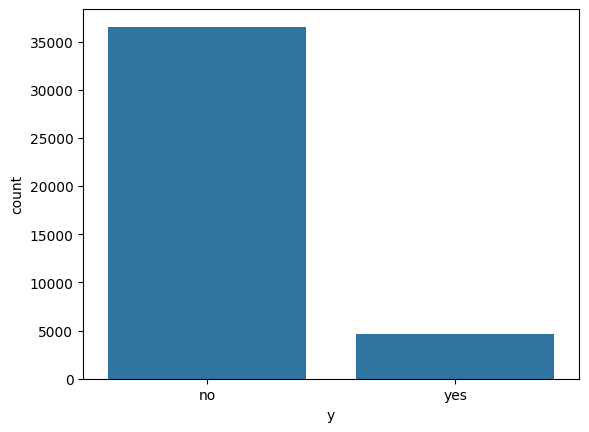

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='y', data=df)
plt.show()

In [43]:
for col in df.columns:
    print(col, df[col].unique()[:5])

age [56 57 37 40 45]
job ['housemaid' 'services' 'admin.' 'blue-collar' 'technician']
marital ['married' 'single' 'divorced' 'unknown']
education ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course']
default ['no' 'unknown' 'yes']
housing ['no' 'yes' 'unknown']
loan ['no' 'yes' 'unknown']
contact ['telephone' 'cellular']
month ['may' 'jun' 'jul' 'aug' 'oct']
day_of_week ['mon' 'tue' 'wed' 'thu' 'fri']
duration [261 149 226 151 307]
campaign [1 2 3 4 5]
pdays [999   6   4   3   5]
previous [0 1 2 3 4]
poutcome ['nonexistent' 'failure' 'success']
emp.var.rate [ 1.1  1.4 -0.1 -0.2 -1.8]
cons.price.idx [93.994 94.465 93.918 93.444 93.798]
cons.conf.idx [-36.4 -41.8 -42.7 -36.1 -40.4]
euribor3m [4.857 4.856 4.855 4.859 4.86 ]
nr.employed [5191.  5228.1 5195.8 5176.3 5099.1]
y ['no' 'yes']


In [44]:
df['y'].value_counts()

,count
y,
no,36537
yes,4639


In [45]:
X = df.drop('y', axis=1)
y = df['y']

In [46]:
X.shape, y.shape

((41176, 20), (41176,))

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
X_train.shape, X_test.shape

((32940, 20), (8236, 20))

In [49]:
cat_cols = X_train.select_dtypes(include='object').columns
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

In [50]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

In [51]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

In [52]:
import numpy as np

X_train_final = np.hstack((X_train_num, X_train_encoded))
X_test_final = np.hstack((X_test_num, X_test_encoded))

In [53]:
X_train_final.shape, X_test_final.shape

((32940, 63), (8236, 63))

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_final = le.fit_transform(y_train)
y_test_final = le.transform(y_test)

In [55]:
np.unique(y_train_final)

array([0, 1])

In [56]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_final, y_train_final)

LogisticRegression(max_iter=1000)

In [57]:
y_pred = lr.predict(X_test_final)

In [58]:
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_final, y_pred)

accuracy

0.9095434677027683

In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test_final, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.65      0.42      0.51       928

    accuracy                           0.91      8236
   macro avg       0.79      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236



In [61]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_final, y_pred)

array([[7099,  209],
       [ 536,  392]])

In [62]:
lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_balanced.fit(X_train_final, y_train_final)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [63]:
y_pred_balanced = lr_balanced.predict(X_test_final)

In [64]:
print(classification_report(y_test_final, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7308
           1       0.45      0.91      0.60       928

    accuracy                           0.86      8236
   macro avg       0.72      0.88      0.76      8236
weighted avg       0.93      0.86      0.88      8236



In [65]:
from sklearn.metrics import roc_auc_score

y_prob = lr_balanced.predict_proba(X_test_final)[:,1]

roc_auc_score(y_test_final, y_prob)

np.float64(0.9402760968140724)

In [66]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_final, y_train_final)

DecisionTreeClassifier(random_state=42)

In [67]:
y_pred_dt = dt.predict(X_test_final)

In [68]:
print(classification_report(y_test_final, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7308
           1       0.51      0.51      0.51       928

    accuracy                           0.89      8236
   macro avg       0.73      0.72      0.73      8236
weighted avg       0.89      0.89      0.89      8236



In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train_final, y_train_final)

RandomForestClassifier(random_state=42)

In [70]:
y_pred_rf = rf.predict(X_test_final)

In [71]:
print(classification_report(y_test_final, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.67      0.47      0.55       928

    accuracy                           0.91      8236
   macro avg       0.80      0.72      0.75      8236
weighted avg       0.90      0.91      0.91      8236



In [72]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42
)

xgb.fit(X_train_final, y_train_final)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [73]:
y_pred_xgb = xgb.predict(X_test_final)

In [74]:
print(classification_report(y_test_final, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7308
           1       0.62      0.55      0.58       928

    accuracy                           0.91      8236
   macro avg       0.78      0.75      0.76      8236
weighted avg       0.91      0.91      0.91      8236



In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred,
    "Balanced Logistic Regression": y_pred_balanced,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for name, pred in models.items():
    print(name)
    print("Accuracy:", accuracy_score(y_test_final, pred))
    print("Precision:", precision_score(y_test_final, pred))
    print("Recall:", recall_score(y_test_final, pred))
    print("F1:", f1_score(y_test_final, pred))
    print("----------------")

Logistic Regression
Accuracy: 0.9095434677027683
Precision: 0.6522462562396006
Recall: 0.4224137931034483
F1: 0.512753433616743
----------------
Balanced Logistic Regression
Accuracy: 0.8642544924720739
Precision: 0.4493603411513859
Recall: 0.9084051724137931
F1: 0.6012838801711841
----------------
Decision Tree
Accuracy: 0.8902379796017484
Precision: 0.512987012987013
Recall: 0.5107758620689655
F1: 0.5118790496760259
----------------
Random Forest
Accuracy: 0.9140359397765906
Precision: 0.6702786377708978
Recall: 0.4665948275862069
F1: 0.5501905972045743
----------------
XGBoost
Accuracy: 0.9107576493443419
Precision: 0.6175395858708892
Recall: 0.5463362068965517
F1: 0.5797598627787307
----------------


In [76]:
from sklearn.model_selection import GridSearchCV

params = {
    'C':[0.01,0.1,1,10],
    'class_weight':['balanced']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_final, y_train_final)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10], 'class_weight': ['balanced']},
             scoring='f1')

In [77]:
grid.best_params_


{'C': 10, 'class_weight': 'balanced'}

In [78]:
best_lr = grid.best_estimator_

y_pred_tuned = best_lr.predict(X_test_final)

print(classification_report(y_test_final, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7308
           1       0.45      0.91      0.60       928

    accuracy                           0.86      8236
   macro avg       0.72      0.88      0.76      8236
weighted avg       0.93      0.86      0.88      8236



In [79]:
import joblib

joblib.dump(best_lr, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [80]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_final, y_pred_tuned)

array([[6280, 1028],
       [  85,  843]])

In [81]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_lr,
    X_train_final,
    y_train_final,
    cv=5,
    scoring='f1'
)

cv_scores

array([0.5881303 , 0.58834001, 0.58139535, 0.58617594, 0.58611362])

In [82]:
cv_scores.mean()

np.float64(0.5860310430262327)

In [83]:
id = "testpred"
y_pred_final = best_lr.predict(X_test_final)

y_pred_final[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [84]:
new_customer = pd.DataFrame({
    'age':[45],
    'job':['admin.'],
    'marital':['married'],
    'education':['high.school'],
    'default':['no'],
    'housing':['yes'],
    'loan':['no'],
    'contact':['cellular'],
    'month':['may'],
    'day_of_week':['mon'],
    'duration':[300],
    'campaign':[2],
    'pdays':[999],
    'previous':[0],
    'poutcome':['nonexistent'],
    'emp.var.rate':[1.1],
    'cons.price.idx':[93.994],
    'cons.conf.idx':[-36.4],
    'euribor3m':[4.857],
    'nr.employed':[5191.0]
})

In [85]:
new_cat = encoder.transform(new_customer[cat_cols])
new_num = scaler.transform(new_customer[num_cols])

new_final = np.hstack((new_num, new_cat))

In [86]:
prediction = best_lr.predict(new_final)

prediction

array([0])